In [28]:
import joblib
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Load Train-Test Data

In [29]:
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (12000, 23)
Testing Features : (3000, 23)
Training Labels  : (12000,)
Testing Labels   : (3000,)


## Create the Baseline XGBoost Model

In [30]:
# Create the baseline XGBoost classifier
baseline_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

print(baseline_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


## Train the Model

In [31]:
# Train the baseline model
baseline_model.fit(X_train, y_train)

print("✅ Baseline XGBoost model trained successfully.")

✅ Baseline XGBoost model trained successfully.


## Make Predictions

In [32]:
# Predict the claim status
y_pred = baseline_model.predict(X_test)

# Predict the probability of denial
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 3000


## Model Evaluation

In [33]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display evaluation metrics
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8037
Precision: 0.3609
Recall   : 0.1125
F1 Score : 0.1716
ROC-AUC  : 0.6394


## Classification Report

In [34]:
# Display the classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      2458
           1       0.36      0.11      0.17       542

    accuracy                           0.80      3000
   macro avg       0.60      0.53      0.53      3000
weighted avg       0.75      0.80      0.76      3000



## Confusion Matrix

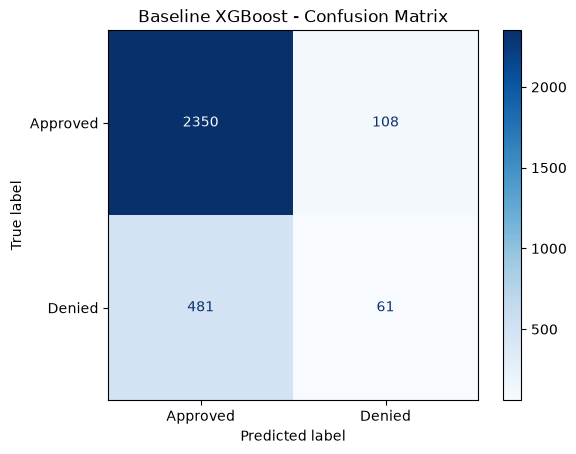

In [35]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Approved", "Denied"]
)

disp.plot(cmap="Blues")

plt.title("Baseline XGBoost - Confusion Matrix")
plt.show()

## Feature Importance

In [36]:
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": baseline_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 important features
feature_importance.head(10)

,Feature,Importance
10,Prior_Auth_Obtained,0.141888
13,NCCI_Bundling_Flag,0.098124
11,Eligibility_Verified,0.084358
12,Duplicate_Claim_Flag,0.072533
14,Clearinghouse_Validation_Passed,0.070902
16,Provider_Payer_Prior_Denial_Count,0.058148
20,Service_DayOfWeek,0.031571
15,Provider_Monthly_Claim_Volume,0.030984
17,Chronic_Condition_Flag,0.030773
6,Modifier_Code,0.030654


## Plot Feature Importance

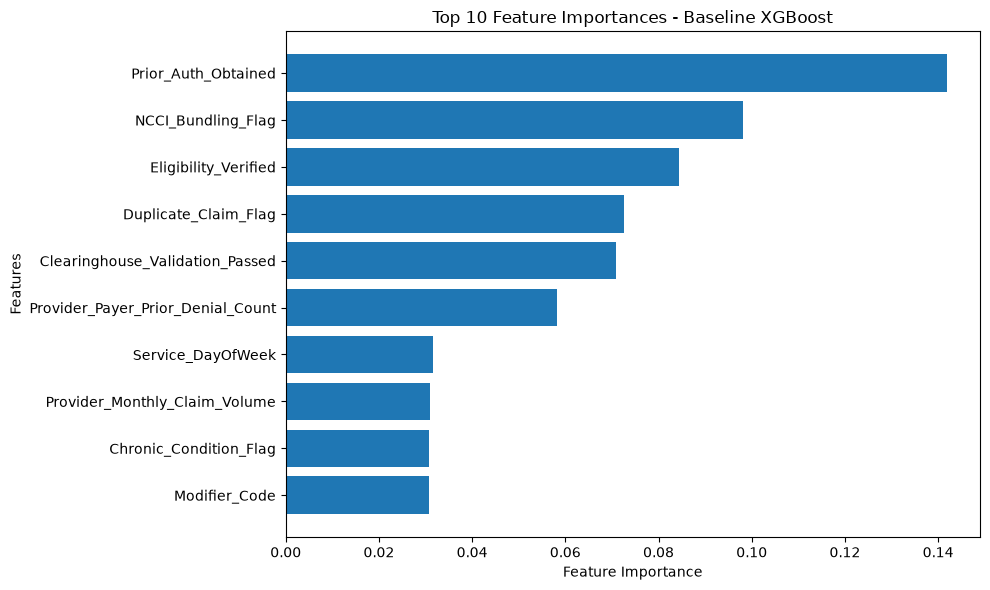

In [38]:
# Plot the top 10 most important features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances - Baseline XGBoost")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Save the base line model

In [39]:
# Save the trained baseline model
joblib.dump(baseline_model, "baseline_xgboost_model.pkl")

print("✅ Baseline XGBoost model saved successfully.")

✅ Baseline XGBoost model saved successfully.
